In [19]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvNeXtTinyPose(nn.Module):
    def __init__(self, num_keypoints=2, dropout_rate=0.3):
        super().__init__()
        self.num_keypoints = num_keypoints
        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=True,
            features_only=True,       
            out_indices=(3,)           
        )
        self.backbone_out_channels = 768

        self.heatmap_head = nn.Sequential(
            nn.Conv2d(self.backbone_out_channels, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, num_keypoints, kernel_size=1)
        )

        self.coord_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),      
            nn.Flatten(),                   
            nn.Linear(self.backbone_out_channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_keypoints * 2) 
        )

    def forward(self, x):
        features = self.backbone(x)[0]   
        heatmaps = self.heatmap_head(features)
        coords = self.coord_head(features)
        batch_size = x.size(0)
        coords = coords.view(batch_size, self.num_keypoints, 2)  

        return heatmaps, coords



    
    

In [17]:
import os
import json
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

/home/mvenkat4/miniconda3/envs/smas/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Epoch [1/60], Train Loss: 3513.7981, Val Loss: 1072.4971
Saved best model at epoch 1 with val loss 1072.4971
Epoch [2/60], Train Loss: 1096.1216, Val Loss: 1122.7648
Epoch [3/60], Train Loss: 1113.6935, Val Loss: 1043.3182
Saved best model at epoch 3 with val loss 1043.3182
Epoch [4/60], Train Loss: 1109.7306, Val Loss: 1043.4706
Epoch [5/60], Train Loss: 1099.5865, Val Loss: 1048.7025
Epoch [6/60], Train Loss: 1094.4302, Val Loss: 1070.4244
Epoch [7/60], Train Loss: 1065.2919, Val Loss: 1029.4114
Saved best model at epoch 7 with val loss 1029.4114
Epoch [8/60], Train Loss: 1072.3756, Val Loss: 1043.4176
Epoch [9/60], Train Loss: 1082.9072, Val Loss: 1044.6133
Epoch [10/60], Train Loss: 1063.2086, Val Loss: 1036.4705
Epoch [11/60], Train Loss: 1055.0238, Val Loss: 1037.7967
Epoch [12/60], Train Loss: 1037.6203, Val Loss: 1027.7239
Saved best model at epoch 12 with val loss 1027.7239
Epoch [13/60], Train Loss: 1051.7658, Val Loss: 1082.6056
Epoch [14/60], Train Loss: 1048.3666, Val Loss

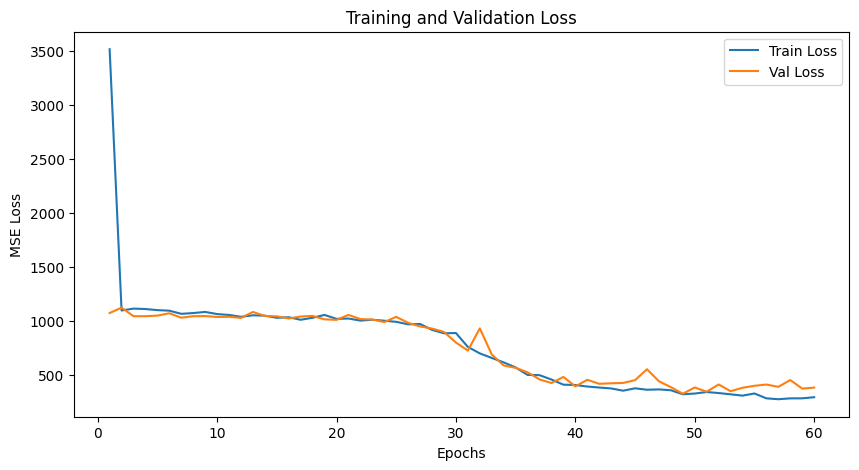

In [30]:
class TopDownKeypointDataset(Dataset):
    def __init__(self, img_folder, json_file, transform=None):
        with open(json_file) as f:
            json_data = json.load(f)
        
        self.img_folder = img_folder
        self.transform = transform


        self.id_to_filename = {img['id']: img['file_name'] for img in json_data['images']}
        

        self.id_to_annots = {}
        for ann in json_data['annotations']:
            image_id = ann['image_id']
            if image_id not in self.id_to_annots:
                self.id_to_annots[image_id] = []
            keypoints = [[ann['keypoints'][i], ann['keypoints'][i+1]] for i in range(0, len(ann['keypoints']), 3)]
            self.id_to_annots[image_id].append({
                'bbox': ann['bbox'],     
                'keypoints': keypoints
            })

        self.image_ids = list(self.id_to_filename.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.img_folder, self.id_to_filename[image_id])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        annot = self.id_to_annots[image_id][0]
        x, y, w, h = annot['bbox']
        keypoints = annot['keypoints']


        x, y, w, h = map(int, [x, y, w, h])
        image_crop = image[y:y+h, x:x+w]

        keypoints = [[kp[0]-x, kp[1]-y] for kp in keypoints]

        if self.transform:
            transformed = self.transform(image=image_crop, keypoints=keypoints)
            image_crop = transformed['image']
            keypoints = transformed['keypoints']

        keypoints = torch.tensor(keypoints, dtype=torch.float32)
        return image_crop, keypoints


train_transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

val_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
], keypoint_params=A.KeypointParams(format='xy'))

train_dataset = TopDownKeypointDataset("/data/marci/SMAS_UTK/train", "/data/marci/SMAS_UTK/train/toes_dataset.json", transform=train_transform)
val_dataset = TopDownKeypointDataset("/data/marci/SMAS_UTK/valid", "/data/marci/SMAS_UTK/valid/toes_dataset.json", transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


gpu_id = 0
device = torch.device(f"cuda:{gpu_id}" if torch.cuda.is_available() else "cpu")
model = ConvNeXtTinyPose(num_keypoints=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()  

num_epochs = 60
train_losses = []
val_losses = []
best_val_loss = float('inf')
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, keypoints in train_loader:
        imgs, keypoints = imgs.to(device), keypoints.to(device)
        optimizer.zero_grad()
        _, preds = model(imgs)
        loss = criterion(preds, keypoints)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for imgs, keypoints in val_loader:
            imgs, keypoints = imgs.to(device), keypoints.to(device)
            _, preds = model(imgs)
            val_loss = criterion(preds, keypoints)
            val_running += val_loss.item() * imgs.size(0)
    val_epoch_loss = val_running / len(val_loader.dataset)
    val_losses.append(val_epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "convnext_tinypose_best.pth")
        print(f"Saved best model at epoch {epoch+1} with val loss {val_epoch_loss:.4f}")

plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


/tmp/ipykernel_1192525/2565034129.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("convnext_tinypose_best.pth"))


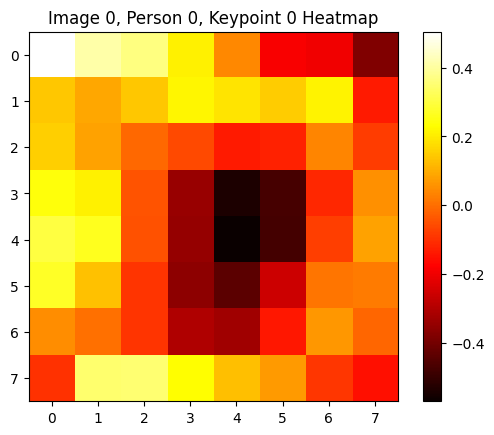

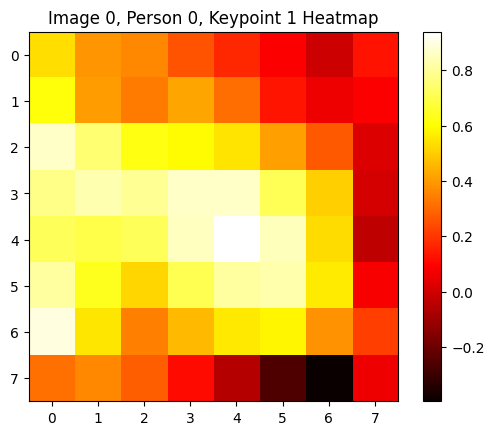

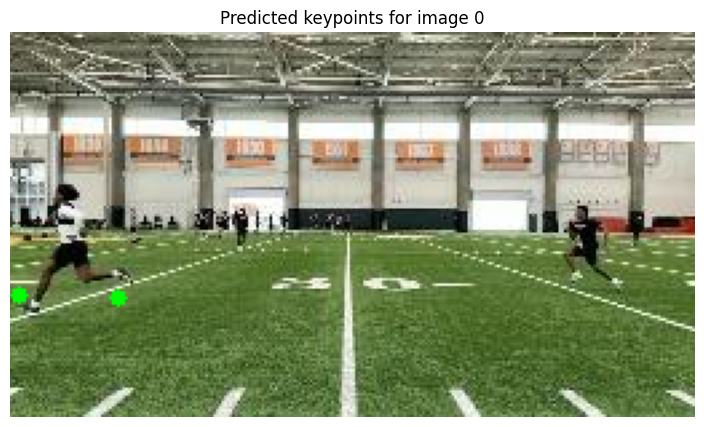

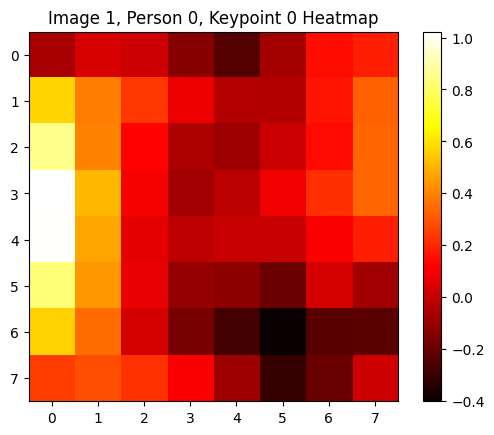

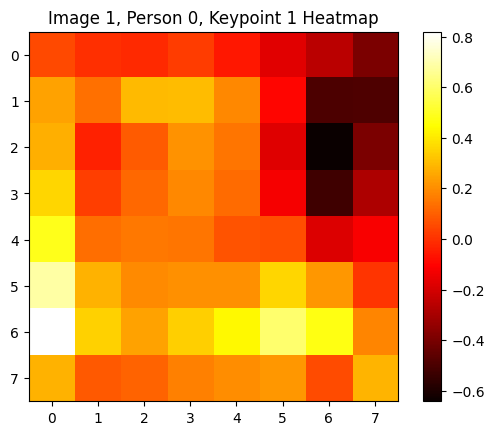

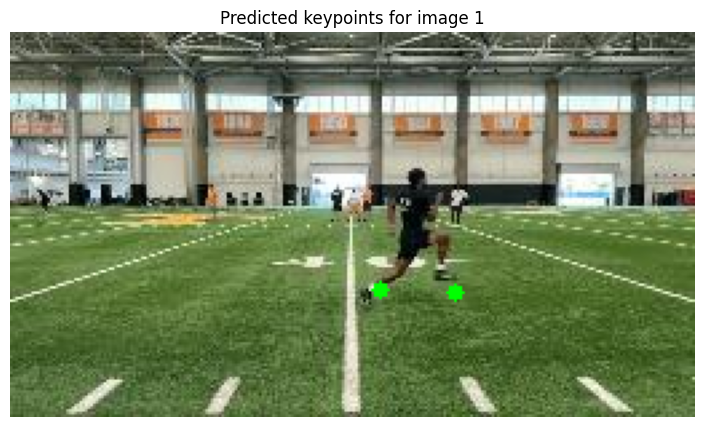

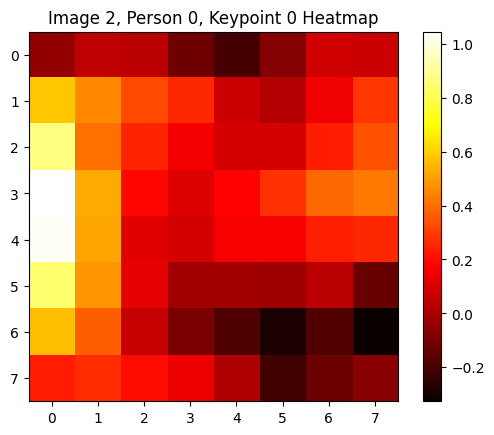

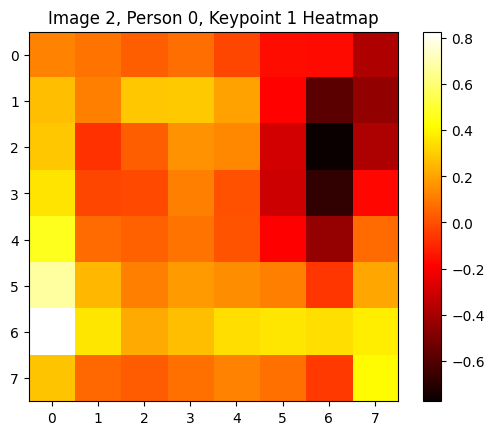

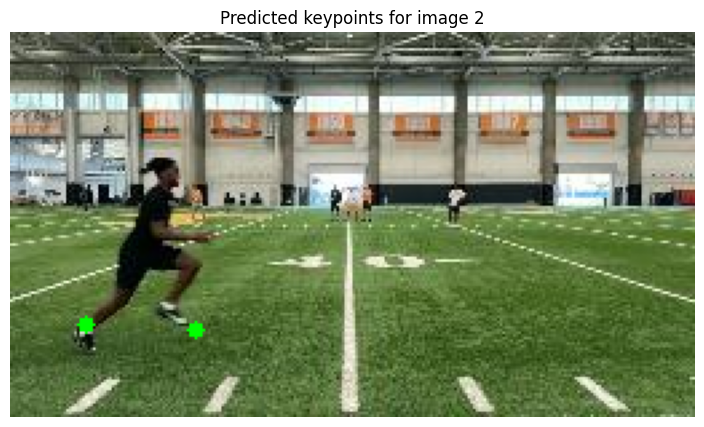

In [32]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import json
import os


model = ConvNeXtTinyPose(num_keypoints=2).to(device)
model.load_state_dict(torch.load("convnext_tinypose_best.pth"))
model.eval()


with open("/data/marci/SMAS_UTK/test/toes_dataset.json") as f:
    test_json = json.load(f)

id_to_filename = {img['id']: img['file_name'] for img in test_json['images']}
id_to_bboxes = {}
for ann in test_json['annotations']:
    image_id = ann['image_id']
    if image_id not in id_to_bboxes:
        id_to_bboxes[image_id] = []
    id_to_bboxes[image_id].append(ann['bbox']) 


for i, image_id in enumerate(list(id_to_filename.keys())[:3]):
    img_path = os.path.join("/data/marci/SMAS_UTK/test", id_to_filename[image_id])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_img = img.copy()

    for bbox_idx, bbox in enumerate(id_to_bboxes[image_id]):
        x0, y0, w, h = map(int, bbox)
        person_crop = img[y0:y0+h, x0:x0+w]

        crop_h, crop_w = person_crop.shape[:2]

        transformed = val_transform(image=person_crop, keypoints=[])
        input_img = transformed['image'].unsqueeze(0).to(device)


        with torch.no_grad():
            heatmaps, preds = model(input_img)
            preds = preds.cpu().numpy()[0]       
            heatmaps = heatmaps.cpu().numpy()[0] 

    
        resized_h, resized_w = input_img.size(2), input_img.size(3)  
        preds[:, 0] = preds[:, 0] * crop_w / resized_w
        preds[:, 1] = preds[:, 1] * crop_h / resized_h

        preds[:, 0] += x0
        preds[:, 1] += y0

        for x, y in preds:
            cv2.circle(orig_img, (int(x), int(y)), 3, (0, 255, 0), -1)

        for kpt_idx, hmap in enumerate(heatmaps):
            plt.figure()
            plt.imshow(hmap, cmap='hot')
            plt.title(f"Image {i}, Person {bbox_idx}, Keypoint {kpt_idx} Heatmap")
            plt.colorbar()
            plt.show()
            
    plt.figure(figsize=(10, 5))
    plt.imshow(orig_img)
    plt.title(f"Predicted keypoints for image {i}")
    plt.axis('off')
    plt.show()
